# Mini caso 3 — Grafo de entidades del corpus documental

Este notebook desarrolla un análisis no supervisado basado en la construcción de un grafo de entidades extraídas del corpus documental del 23-F.

El objetivo es identificar qué personas, instituciones y lugares aparecen de forma recurrente en los documentos, y estudiar cómo se relacionan entre sí cuando coinciden dentro de un mismo documento.

La lógica del mini caso es la siguiente:

- extraer entidades nombradas del texto limpio;
- filtrar entidades relevantes;
- construir relaciones de coaparición entre entidades dentro de cada documento;
- crear un grafo ponderado;
- analizar las entidades más centrales;
- visualizar un subgrafo interpretable.

Este análisis no pretende demostrar causalidad ni relaciones históricas directas. Una arista entre dos entidades indica únicamente que ambas aparecen en el mismo documento. Por tanto, el grafo debe interpretarse como una herramienta exploratoria para navegar el corpus y detectar actores o instituciones relevantes.

In [1]:
from pathlib import Path

import pandas as pd

current_path = Path.cwd().resolve()

if (current_path / "data").exists() and (current_path / "notebooks").exists():
    ROOT = current_path
elif (current_path.parent / "data").exists() and (current_path.parent / "notebooks").exists():
    ROOT = current_path.parent
else:
    raise FileNotFoundError("No se ha podido localizar la raíz del repositorio.")

DATA_PROCESSED = ROOT / "data" / "processed"

input_path = DATA_PROCESSED / "rtve_corpus_clean_base.csv"

df = pd.read_csv(input_path)

print(f"Archivo cargado: {input_path}")
print(f"Dimensiones: {df.shape}")

display(df.head())

Archivo cargado: /Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/data/processed/rtve_corpus_clean_base.csv
Dimensiones: (167, 25)


,doc_id,source_document_id,title,pages,detail_url,pdf_url,summary,keywords,text_full,text_clean_base,...,moncloa_section,moncloa_subsection,final_match_status,coverage_moncloa,alpha_ratio,digit_ratio,uppercase_ratio,weird_char_ratio,n_title_years,title_main_year
0,rtve_1860,1860,Vista oral 2/81 del Consejo Supremo de Justici...,3,https://23fbuscador.rtve.es/document/ocr/1860?...,https://www.rtve.es/contenidos/documentos/23f-...,El juicio oral 2/81 celebrado en febrero de 19...,C/SG/2820/20-02-82 DTOR. Vista oral 2/81,C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\...,C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\...,...,defensa,cni,high_confidence_match,True,0.777834,0.013726,0.147386,0.000000,1,1982.0
1,rtve_1859,1859,Vista oral 2/81 del Consejo Supremo de Justici...,4,https://23fbuscador.rtve.es/document/ocr/1859?...,https://www.rtve.es/contenidos/documentos/23f-...,Resumen global del documento:\n\nEl documento ...,C/SG/2896/22-02-82 Vista oral 2/81 Consejo Sup...,C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nAS...,C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nAS...,...,defensa,cni,high_confidence_match,True,0.781985,0.009506,0.195895,0.000156,1,1982.0
2,rtve_1858,1858,Vista oral 2/81 del Consejo Supremo de Justici...,5,https://23fbuscador.rtve.es/document/ocr/1858?...,https://www.rtve.es/contenidos/documentos/23f-...,Resumen global del documento:\n\nEl documento ...,C/SG/2992/24-02-82 Vista Oral 2/81 Consejo Sup...,C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nAS...,C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nAS...,...,defensa,cni,high_confidence_match,True,0.784920,0.011487,0.124085,0.000611,1,1982.0
3,rtve_1857,1857,Vista oral 2/81 del Consejo Supremo de Justici...,6,https://23fbuscador.rtve.es/document/ocr/1857?...,https://www.rtve.es/contenidos/documentos/23f-...,El documento recoge el desarrollo de la sesión...,C/SG/3.081/25-02-82 Vista Oral 2/81 Consejo Su...,C/SG/3.081/25-02-82\n\n# NOTA INFORMATIVA\n\nA...,C/SG/3.081/25-02-82\n\n# NOTA INFORMATIVA\n\nA...,...,defensa,cni,high_confidence_match,True,0.789257,0.008250,0.128167,0.000538,1,1982.0
4,rtve_1856,1856,Vista oral 2/81 del Consejo Supremo de Justici...,6,https://23fbuscador.rtve.es/document/ocr/1856?...,https://www.rtve.es/contenidos/documentos/23f-...,Resumen global del documento sobre la sesión d...,C/SG/3.249/26-02-82 SG Consejo Supremo de Just...,C/SG/3.249/26-02-82\nSG\n\n# NOTA INFORMATIVA\...,C/SG/3.249/26-02-82\nSG\n\n# NOTA INFORMATIVA\...,...,defensa,cni,high_confidence_match,True,0.786053,0.008593,0.066097,0.000691,1,1982.0


## 1. Selección de datos

Para construir el grafo se utilizan los documentos del corpus limpio que tienen texto disponible en la columna `text_clean_base`.

Además del texto, se conservan varias columnas de apoyo:

- `doc_id`, para mantener la trazabilidad del documento;
- `title`, para poder revisar ejemplos concretos;
- `moncloa_section`, como metadato auxiliar de interpretación;
- `text_clean_length_words`, para controlar la longitud de los textos.

La extracción de entidades se realizará sobre `text_clean_base`. No se utiliza ninguna etiqueta como variable objetivo, ya que este mini caso tiene un carácter exploratorio.

In [2]:
df_text = df[
    [
        "doc_id",
        "title",
        "text_clean_base",
        "text_clean_length_words",
        "moncloa_section",
    ]
].copy()

df_text = df_text[
    df_text["text_clean_base"].notna()
    & (df_text["text_clean_length_words"] >= 50)
].copy()

print("Documentos seleccionados:")
print(df_text.shape)

print("\nResumen de longitud de textos:")
display(df_text["text_clean_length_words"].describe().to_frame().T)

display(
    df_text[
        ["doc_id", "title", "text_clean_length_words", "moncloa_section"]
    ].head()
)

Documentos seleccionados:
(167, 5)

Resumen de longitud de textos:


,count,mean,std,min,25%,50%,75%,max
text_clean_length_words,167.0,2075.443114,7731.242472,72.0,238.5,579.0,1771.5,95293.0


,doc_id,title,text_clean_length_words,moncloa_section
0,rtve_1860,Vista oral 2/81 del Consejo Supremo de Justici...,640,defensa
1,rtve_1859,Vista oral 2/81 del Consejo Supremo de Justici...,1018,defensa
2,rtve_1858,Vista oral 2/81 del Consejo Supremo de Justici...,1347,defensa
3,rtve_1857,Vista oral 2/81 del Consejo Supremo de Justici...,1826,defensa
4,rtve_1856,Vista oral 2/81 del Consejo Supremo de Justici...,1740,defensa


## 2. Carga del modelo NLP

Para extraer entidades nombradas se utiliza spaCy, una librería de procesamiento del lenguaje natural.

El modelo `es_core_news_sm` permite detectar entidades como personas, organizaciones y lugares en textos en español. En este mini caso se utiliza como herramienta de extracción inicial, pero sus resultados deben interpretarse con cautela porque el corpus contiene documentos históricos, textos administrativos y posibles errores derivados del OCR.

In [3]:
import spacy

nlp = spacy.load("es_core_news_sm")

print("Modelo spaCy cargado correctamente: es_core_news_sm")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/gabrielrezola/Library/Python/3.11/lib/python/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/gabrielrezola/Library/Python/3.11/lib/python/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/gabrielrezola/Library/Python/3.11/lib/python/site-packages/ipykernel/kernelapp.py", line 758, in start
  

Modelo spaCy cargado correctamente: es_core_news_sm


## 3. Extracción de entidades

En este bloque se extraen entidades nombradas de cada documento mediante el modelo NLP cargado previamente.

Para evitar que los documentos muy extensos generen tiempos de ejecución excesivos y demasiadas relaciones poco interpretables, se limita el texto analizado de cada documento a un máximo de caracteres. Esta decisión mantiene el análisis manejable y reduce el ruido del grafo.

Las entidades extraídas se almacenan inicialmente junto con su etiqueta original del modelo.

In [4]:
MAX_CHARS = 15000

def extract_entities(text):
    text = str(text)[:MAX_CHARS]
    doc = nlp(text)

    entities = []

    for ent in doc.ents:
        entities.append(
            {
                "entity": ent.text,
                "label": ent.label_
            }
        )

    return entities


df_text["entities_raw"] = df_text["text_clean_base"].apply(extract_entities)

print("Extracción de entidades completada.")

display(
    df_text[
        ["doc_id", "title", "entities_raw"]
    ].head()
)

Extracción de entidades completada.


,doc_id,title,entities_raw
0,rtve_1860,Vista oral 2/81 del Consejo Supremo de Justici...,"[{'entity': 'C', 'label': 'MISC'}, {'entity': ..."
1,rtve_1859,Vista oral 2/81 del Consejo Supremo de Justici...,"[{'entity': 'C', 'label': 'MISC'}, {'entity': ..."
2,rtve_1858,Vista oral 2/81 del Consejo Supremo de Justici...,"[{'entity': 'C', 'label': 'MISC'}, {'entity': ..."
3,rtve_1857,Vista oral 2/81 del Consejo Supremo de Justici...,"[{'entity': 'C', 'label': 'MISC'}, {'entity': ..."
4,rtve_1856,Vista oral 2/81 del Consejo Supremo de Justici...,"[{'entity': 'C', 'label': 'MISC'}, {'entity': ..."


## 4. Filtrado y normalización de entidades

La extracción inicial de entidades contiene ruido propio del corpus: abreviaturas, letras aisladas, referencias administrativas y errores derivados del OCR.

Por ello, antes de construir el grafo se aplica un filtrado básico. Se conservan únicamente entidades de tipo persona, organización y lugar, y se normaliza el texto de cada entidad para reducir duplicados simples.

Este paso no elimina todos los problemas de reconocimiento de entidades, pero permite obtener una base más limpia para construir relaciones de coaparición.

In [5]:
import re

VALID_LABELS = {"PER", "ORG", "LOC"}

def normalize_entity(entity):
    entity = str(entity).strip()
    entity = re.sub(r"\s+", " ", entity)
    entity = entity.strip(".,;:-()[]{}")
    return entity


def filter_entities(entities):
    filtered = []

    for ent in entities:
        entity = normalize_entity(ent["entity"])
        label = ent["label"]

        if label not in VALID_LABELS:
            continue

        if len(entity) < 3:
            continue

        if entity.isdigit():
            continue

        if entity.lower() in {"nota", "asunto", "fecha", "documento"}:
            continue

        filtered.append(
            {
                "entity": entity,
                "label": label
            }
        )

    return filtered


df_text["entities_filtered"] = df_text["entities_raw"].apply(filter_entities)

print("Filtrado de entidades completado.")

display(
    df_text[
        ["doc_id", "title", "entities_filtered"]
    ].head()
)

Filtrado de entidades completado.


,doc_id,title,entities_filtered
0,rtve_1860,Vista oral 2/81 del Consejo Supremo de Justici...,"[{'entity': 'DTOR', 'label': 'ORG'}, {'entity'..."
1,rtve_1859,Vista oral 2/81 del Consejo Supremo de Justici...,[{'entity': 'Consejo Supremo de Justicia Milit...
2,rtve_1858,Vista oral 2/81 del Consejo Supremo de Justici...,[{'entity': 'Consejo Supremo de Justicia Milit...
3,rtve_1857,Vista oral 2/81 del Consejo Supremo de Justici...,[{'entity': 'Consejo Supremo de Justicia Milit...
4,rtve_1856,Vista oral 2/81 del Consejo Supremo de Justici...,[{'entity': 'Consejo Supremo de Justicia Milit...


### Lectura del bloque

Tras aplicar el filtrado, se conservan únicamente entidades reconocidas como personas, organizaciones o lugares. Este paso reduce parte del ruido inicial generado por el OCR y por las fórmulas administrativas de los documentos.

Aun así, todavía pueden aparecer entidades poco informativas, como abreviaturas internas o referencias administrativas. Por ello, antes de construir el grafo será necesario revisar la frecuencia de aparición de las entidades y aplicar filtros adicionales.

## 5. Análisis de entidades extraídas

Antes de construir el grafo, se transforma la lista de entidades filtradas en una tabla estructurada. Esto permite revisar qué entidades aparecen con mayor frecuencia y detectar posibles elementos poco informativos.

Este paso es importante porque el reconocimiento automático de entidades puede mantener ruido procedente del OCR, abreviaturas administrativas o expresiones demasiado genéricas.

In [6]:
entity_rows = []

for _, row in df_text.iterrows():
    for ent in row["entities_filtered"]:
        entity_rows.append(
            {
                "doc_id": row["doc_id"],
                "title": row["title"],
                "moncloa_section": row["moncloa_section"],
                "entity": ent["entity"],
                "label": ent["label"],
            }
        )

df_entities = pd.DataFrame(entity_rows)

print("Número total de menciones de entidades:")
print(len(df_entities))

print("\nNúmero de entidades únicas:")
print(df_entities["entity"].nunique())

display(df_entities.head())

Número total de menciones de entidades:
11483

Número de entidades únicas:
4565


,doc_id,title,moncloa_section,entity,label
0,rtve_1860,Vista oral 2/81 del Consejo Supremo de Justici...,defensa,DTOR,ORG
1,rtve_1860,Vista oral 2/81 del Consejo Supremo de Justici...,defensa,1.- DESARROLLO,LOC
2,rtve_1860,Vista oral 2/81 del Consejo Supremo de Justici...,defensa,Solo,PER
3,rtve_1860,Vista oral 2/81 del Consejo Supremo de Justici...,defensa,Empezó,PER
4,rtve_1860,Vista oral 2/81 del Consejo Supremo de Justici...,defensa,Ayte,LOC


In [7]:
entity_frequency = (
    df_entities
    .groupby(["entity", "label"])
    .agg(
        n_menciones=("entity", "size"),
        n_documentos=("doc_id", "nunique")
    )
    .reset_index()
    .sort_values(["n_documentos", "n_menciones"], ascending=False)
)

display(entity_frequency.head(30))

,entity,label,n_menciones,n_documentos
2965,Madrid,LOC,123,76
1072,Congreso,ORG,282,57
3886,Rey,PER,181,52
2343,Guardia Civil,ORG,134,52
2115,General,LOC,136,42
5,1.- DESARROLLO,LOC,38,38
1647,ESTIMACIONES,ORG,37,37
3971,SESION,ORG,37,37
3653,Presidente,PER,91,36
1840,España,PER,75,36


### Lectura del bloque

La tabla de frecuencia muestra que el reconocimiento automático de entidades detecta elementos relevantes del corpus, como `Madrid`, `Congreso`, `Guardia Civil`, `CESID`, `General Armada` o `López Montero`.

Sin embargo, también aparecen entidades poco informativas o ruidosas, como encabezados administrativos, cargos genéricos, fórmulas documentales y palabras reconocidas erróneamente como entidades. Este comportamiento es esperable en un corpus histórico con documentos OCR y textos administrativos.

Por ello, antes de construir el grafo se aplica un filtrado adicional para eliminar entidades demasiado genéricas o claramente procedentes del formato documental.

In [8]:
NOISE_ENTITIES = {
    "DTOR",
    "1.- DESARROLLO",
    "2.- INCIDENCIAS",
    "ESTIMACIONES",
    "SESION",
    "Dios",
    "También",
    "Solo",
    "Empezó",
    "Ayte",
    "DIRECCION",
    "General",
    "Presidente",
    "Capitán",
    "Tribunal",
    "Capitán General",
    "S.M",
    "Sólo",
    "Tcol",
    "Coronel",
    "Tenientes",
    "Capitanes",
    "Generales",
    "Jefe",
    "Unidad",
    "Cuerpo",
    "Sala",
}

def is_valid_entity_for_graph(entity):
    entity = str(entity).strip()

    if entity in NOISE_ENTITIES:
        return False

    if len(entity) < 4:
        return False

    if entity.isupper() and len(entity) <= 4:
        return False

    return True


df_entities_clean = df_entities[
    df_entities["entity"].apply(is_valid_entity_for_graph)
].copy()

print("Menciones antes del filtrado adicional:")
print(len(df_entities))

print("\nMenciones después del filtrado adicional:")
print(len(df_entities_clean))

print("\nEntidades únicas antes:")
print(df_entities["entity"].nunique())

print("\nEntidades únicas después:")
print(df_entities_clean["entity"].nunique())

entity_frequency_clean = (
    df_entities_clean
    .groupby(["entity", "label"])
    .agg(
        n_menciones=("entity", "size"),
        n_documentos=("doc_id", "nunique")
    )
    .reset_index()
    .sort_values(["n_documentos", "n_menciones"], ascending=False)
)

display(entity_frequency_clean.head(30))

Menciones antes del filtrado adicional:
11483

Menciones después del filtrado adicional:
9599

Entidades únicas antes:
4565

Entidades únicas después:
4337


,entity,label,n_menciones,n_documentos
2835,Madrid,LOC,123,76
1026,Congreso,ORG,282,57
2242,Guardia Civil,ORG,134,52
1753,España,PER,75,36
2027,General Armada,PER,172,34
591,CESID,ORG,115,32
375,Armada,ORG,73,30
1088,Constitución,LOC,47,29
1025,Congreso,LOC,49,28
1751,España,LOC,43,26


### Control metodológico

El filtrado adicional se basa únicamente en características textuales de las entidades extraídas: longitud, forma, presencia en una lista de ruido documental y carácter genérico de algunos términos.

No se utiliza `moncloa_section` ni ninguna etiqueta institucional para construir el grafo. Esta columna se conserva únicamente como metadato auxiliar para interpretar los resultados una vez construido el grafo.

Por tanto, el análisis mantiene un carácter no supervisado y exploratorio. Las relaciones del grafo se basarán exclusivamente en la coaparición de entidades dentro de los documentos.

## 6. Construcción de relaciones de coaparición

Una vez filtradas las entidades, se construyen relaciones de coaparición entre entidades que aparecen dentro de un mismo documento.

En este mini caso, una relación no implica causalidad ni vínculo histórico directo. Solo indica que dos entidades han sido mencionadas en el mismo documento. Por tanto, el grafo se interpreta como una red exploratoria de proximidad documental.

Para reducir ruido, se conservan únicamente entidades que aparecen en varios documentos y relaciones que se repiten al menos en más de un documento.

In [9]:
from itertools import combinations
from collections import Counter

# Normalización mínima de nombres para reducir duplicados evidentes
ENTITY_NORMALIZATION = {
    "MADRID": "Madrid",
    "ESPAÑA": "España",
    "España": "España",
    "la Zarzuela": "Zarzuela",
}

df_entities_clean["entity_norm"] = (
    df_entities_clean["entity"]
    .replace(ENTITY_NORMALIZATION)
    .str.strip()
)

# Tabla documento-entidad: una entidad cuenta una vez por documento
df_entity_doc = (
    df_entities_clean[
        ["doc_id", "title", "moncloa_section", "entity_norm", "label"]
    ]
    .drop_duplicates(subset=["doc_id", "entity_norm"])
    .copy()
)

# Frecuencia documental de cada entidad
entity_doc_frequency = (
    df_entity_doc
    .groupby("entity_norm")
    .agg(
        n_documentos=("doc_id", "nunique"),
        label_mas_frecuente=("label", lambda x: x.value_counts().idxmax())
    )
    .reset_index()
    .sort_values("n_documentos", ascending=False)
)

# Se conservan solo entidades que aparecen en al menos 3 documentos
MIN_ENTITY_DOCS = 3

valid_entities = set(
    entity_doc_frequency[
        entity_doc_frequency["n_documentos"] >= MIN_ENTITY_DOCS
    ]["entity_norm"]
)

df_graph_entities = df_entity_doc[
    df_entity_doc["entity_norm"].isin(valid_entities)
].copy()

# Construcción de aristas por coaparición dentro de cada documento
edge_counter = Counter()

for doc_id, group in df_graph_entities.groupby("doc_id"):
    entities_in_doc = sorted(group["entity_norm"].unique())

    for entity_a, entity_b in combinations(entities_in_doc, 2):
        edge_counter[(entity_a, entity_b)] += 1

df_edges = pd.DataFrame(
    [
        {
            "source": source,
            "target": target,
            "weight": weight
        }
        for (source, target), weight in edge_counter.items()
    ]
)

# Se conservan solo relaciones que aparecen en al menos 2 documentos
MIN_EDGE_WEIGHT = 2

df_edges = df_edges[
    df_edges["weight"] >= MIN_EDGE_WEIGHT
].copy()

df_edges = df_edges.sort_values("weight", ascending=False)

print("Entidades válidas para el grafo:")
print(len(valid_entities))

print("\nNúmero de relaciones conservadas:")
print(len(df_edges))

display(df_edges.head(30))

Entidades válidas para el grafo:
436

Número de relaciones conservadas:
6728


,source,target,weight
645,Congreso,Guardia Civil,39
335,Congreso,España,31
643,Congreso,General Armada,29
552,España,Guardia Civil,26
396,España,Madrid,26
5295,CESID,Congreso,26
4376,Armada,Congreso,25
332,Congreso,Constitución,24
2014,Constitución,Guardia Civil,24
225,Guardia Civil,Madrid,23


## 7. Creación del grafo

A partir de las relaciones de coaparición se construye un grafo no dirigido y ponderado.

Cada nodo representa una entidad extraída del corpus documental. Cada arista representa una relación de coaparición entre dos entidades dentro de uno o varios documentos. El peso de la arista indica en cuántos documentos aparecen juntas ambas entidades.

El grafo se construye como una red no dirigida porque, en este análisis, no se estudia quién actúa sobre quién, sino simplemente qué entidades aparecen próximas dentro del corpus.

In [10]:
import networkx as nx

G = nx.Graph()

# Añadir nodos con atributos básicos
node_info = (
    df_graph_entities
    .groupby("entity_norm")
    .agg(
        n_documentos=("doc_id", "nunique"),
        label_mas_frecuente=("label", lambda x: x.value_counts().idxmax())
    )
    .reset_index()
)

for _, row in node_info.iterrows():
    G.add_node(
        row["entity_norm"],
        n_documentos=row["n_documentos"],
        label=row["label_mas_frecuente"]
    )

# Añadir aristas ponderadas
for _, row in df_edges.iterrows():
    G.add_edge(
        row["source"],
        row["target"],
        weight=row["weight"]
    )

print("Grafo creado correctamente.")
print(f"Número de nodos: {G.number_of_nodes()}")
print(f"Número de aristas: {G.number_of_edges()}")
print(f"Densidad del grafo: {nx.density(G):.4f}")
print(f"Número de componentes conectados: {nx.number_connected_components(G)}")

Grafo creado correctamente.
Número de nodos: 436
Número de aristas: 6728
Densidad del grafo: 0.0709
Número de componentes conectados: 4


### Lectura del bloque

El grafo construido contiene 436 nodos y 6.728 aristas ponderadas. Cada nodo representa una entidad extraída del corpus y cada arista indica que dos entidades coaparecen en al menos dos documentos.

La densidad del grafo es de 0,0709, lo que indica una red con un nivel moderado de conexión. No se trata de un grafo completamente denso, pero sí de una red suficientemente conectada como para identificar entidades centrales y relaciones recurrentes.

El grafo está formado por 4 componentes conectados. Esto sugiere la existencia de una componente principal donde se concentran la mayoría de entidades relevantes, junto con algunos subconjuntos menores de entidades que no están conectados con el resto de la red.

Dado el tamaño del grafo, la visualización completa no sería interpretable. Por ello, el análisis posterior se centra en métricas de centralidad y en la visualización de un subgrafo filtrado.

## 8. Análisis del grafo

Una vez construido el grafo, se calculan métricas básicas para identificar las entidades más relevantes dentro de la red.

Se analizan principalmente tres aspectos:

- el grado ponderado, que mide la intensidad total de las relaciones de una entidad;
- la centralidad de grado, que indica qué entidades están conectadas con más nodos;
- las aristas con mayor peso, que representan las coapariciones más repetidas en el corpus.

Estas métricas permiten detectar actores, instituciones y lugares especialmente centrales en la estructura documental del corpus.

In [11]:
# Métricas de nodos
degree_centrality = nx.degree_centrality(G)
weighted_degree = dict(G.degree(weight="weight"))

node_metrics = []

for node in G.nodes():
    node_metrics.append(
        {
            "entity": node,
            "label": G.nodes[node].get("label"),
            "n_documentos": G.nodes[node].get("n_documentos"),
            "degree_centrality": degree_centrality[node],
            "weighted_degree": weighted_degree[node],
        }
    )

df_node_metrics = (
    pd.DataFrame(node_metrics)
    .sort_values("weighted_degree", ascending=False)
)

display(df_node_metrics.head(30))

,entity,label,n_documentos,degree_centrality,weighted_degree
94,Congreso,ORG,59,0.754023,1586
214,Guardia Civil,ORG,52,0.788506,1451
160,España,PER,58,0.696552,1165
258,Madrid,LOC,82,0.671264,1043
187,General Armada,PER,34,0.533333,925
105,Constitución,LOC,34,0.600000,922
29,Armada,ORG,30,0.487356,847
53,CESID,ORG,32,0.485057,762
406,Valencia,LOC,25,0.450575,722
206,Gobierno,LOC,27,0.379310,537


### Lectura del bloque

Las métricas de centralidad muestran que las entidades más relevantes del grafo son principalmente instituciones, lugares y actores directamente vinculados al contexto documental del 23-F.

Destacan entidades como `Congreso`, `Guardia Civil`, `España`, `Madrid`, `General Armada`, `Constitución`, `Armada`, `CESID`, `Valencia` y `Gobierno`. Su posición central indica que aparecen conectadas con muchas otras entidades y que coaparecen de forma recurrente en distintos documentos del corpus.

El grado ponderado permite identificar no solo cuántas conexiones tiene cada entidad, sino también la intensidad acumulada de esas relaciones. Por ejemplo, `Congreso` y `Guardia Civil` presentan valores especialmente elevados, lo que refleja su presencia transversal en numerosos documentos y su coaparición con múltiples actores e instituciones.

Aun así, todavía aparecen algunas entidades parcialmente ruidosas o ambiguas, como cargos, abreviaturas o nombres incompletos. Este aspecto es una limitación habitual en análisis de entidades nombradas sobre corpus históricos y documentos procedentes de OCR.

## 9. Visualización del subgrafo principal

La visualización completa del grafo no resulta interpretable debido al número de nodos y relaciones. Por ello, se construye un subgrafo reducido a partir de las entidades con mayor grado ponderado.

Esta visualización permite observar la estructura principal de coaparición entre las entidades más centrales del corpus, manteniendo un tamaño legible.

El gráfico debe entenderse como una representación exploratoria: la proximidad visual depende del algoritmo de disposición del grafo y no implica necesariamente una relación histórica directa.

Subgrafo para visualización:
Número de nodos: 20
Número de aristas: 76


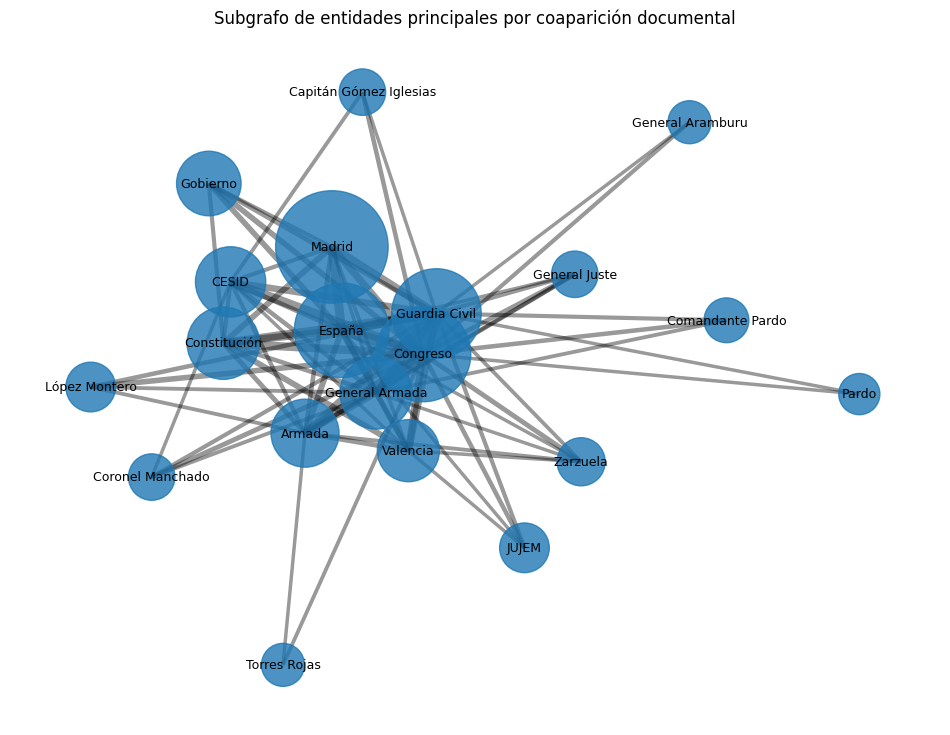

In [12]:
import matplotlib.pyplot as plt

# Selección de nodos principales por grado ponderado
TOP_NODES = 20

top_nodes = (
    df_node_metrics
    .sort_values("weighted_degree", ascending=False)
    .head(TOP_NODES)["entity"]
    .tolist()
)

G_sub = G.subgraph(top_nodes).copy()

# Eliminar aristas débiles dentro del subgrafo para mejorar legibilidad
MIN_VISUAL_EDGE_WEIGHT = 10

edges_to_remove = [
    (u, v)
    for u, v, data in G_sub.edges(data=True)
    if data.get("weight", 1) < MIN_VISUAL_EDGE_WEIGHT
]

G_sub.remove_edges_from(edges_to_remove)

# Eliminar nodos aislados tras el filtrado de aristas
isolated_nodes = list(nx.isolates(G_sub))
G_sub.remove_nodes_from(isolated_nodes)

print("Subgrafo para visualización:")
print(f"Número de nodos: {G_sub.number_of_nodes()}")
print(f"Número de aristas: {G_sub.number_of_edges()}")

plt.figure(figsize=(12, 9))

pos = nx.spring_layout(
    G_sub,
    seed=42,
    k=0.8,
    weight="weight"
)

node_sizes = [
    G_sub.nodes[node].get("n_documentos", 1) * 80
    for node in G_sub.nodes()
]

edge_widths = [
    G_sub[u][v].get("weight", 1) / 4
    for u, v in G_sub.edges()
]

nx.draw_networkx_nodes(
    G_sub,
    pos,
    node_size=node_sizes,
    alpha=0.8
)

nx.draw_networkx_edges(
    G_sub,
    pos,
    width=edge_widths,
    alpha=0.4
)

nx.draw_networkx_labels(
    G_sub,
    pos,
    font_size=9
)

plt.title("Subgrafo de entidades principales por coaparición documental")
plt.axis("off")
plt.show()

### Lectura del bloque

La visualización del subgrafo principal permite observar de forma más clara la estructura central de coapariciones del corpus.

Para evitar una representación ilegible, se han seleccionado las 20 entidades con mayor grado ponderado y se han conservado únicamente las relaciones con un peso mínimo de 10. De este modo, el gráfico muestra las conexiones más recurrentes entre las entidades principales.

El subgrafo mantiene entidades claramente centrales como `Congreso`, `Guardia Civil`, `Madrid`, `España`, `General Armada`, `CESID`, `Armada`, `Constitución` y `Valencia`. Estas entidades aparecen conectadas con múltiples actores, instituciones y lugares, lo que refleja su presencia transversal en el corpus documental.

La visualización debe interpretarse como una herramienta exploratoria. La posición de los nodos depende del algoritmo de disposición del grafo y las aristas representan coaparición documental, no necesariamente relaciones causales o históricas directas.

## 10. Conclusiones y limitaciones

El mini caso ha permitido construir un grafo exploratorio de entidades a partir del corpus documental del 23-F. A partir de los textos limpios se han extraído entidades nombradas, se han filtrado las más relevantes y se han construido relaciones de coaparición entre entidades mencionadas dentro de un mismo documento.

El resultado muestra una red documental centrada en entidades como `Congreso`, `Guardia Civil`, `Madrid`, `España`, `General Armada`, `CESID`, `Armada`, `Constitución`, `Valencia` y `Gobierno`. Estas entidades presentan valores elevados de centralidad y grado ponderado, lo que indica que aparecen conectadas de forma recurrente con múltiples actores, instituciones y lugares del corpus.

El análisis de aristas permite identificar las coapariciones más frecuentes entre entidades. Estas relaciones no deben interpretarse como vínculos causales ni como relaciones históricas directas, sino como proximidad documental: dos entidades aparecen conectadas porque han sido mencionadas dentro de los mismos documentos.

La visualización del subgrafo principal facilita la interpretación de la estructura central de la red. Al limitar la representación a las entidades con mayor grado ponderado y a las relaciones más frecuentes, se obtiene una imagen más legible de los actores e instituciones que articulan el corpus.

Como limitación principal, el análisis depende de la calidad de la extracción automática de entidades. Al tratarse de documentos históricos, administrativos y procedentes de OCR, pueden aparecer entidades ruidosas, cargos genéricos, abreviaturas o nombres parcialmente reconocidos. Aunque se ha aplicado un filtrado adicional, el resultado no debe entenderse como una base de conocimiento perfecta, sino como una herramienta exploratoria.

Otra limitación es que el grafo se basa únicamente en coaparición dentro del mismo documento. Esto permite detectar proximidad documental, pero no distingue entre tipos de relación, dirección, relevancia histórica o contexto semántico concreto.

Como ampliación futura, podrían aplicarse técnicas más avanzadas de normalización de entidades, diferenciación entre personas, instituciones y cargos, análisis temporal por fechas de los documentos o construcción de grafos específicos por sección institucional.